In [13]:
%matplotlib inline
%config InlineBackend.figure_format ='retina'
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

In [14]:
import numpy as np
from sklearn.decomposition import PCA
from tqdm.autonotebook import trange

/tmp/ipykernel_67978/2174192030.py:3: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import trange


slide N18 from lecture about PCA algorithm:


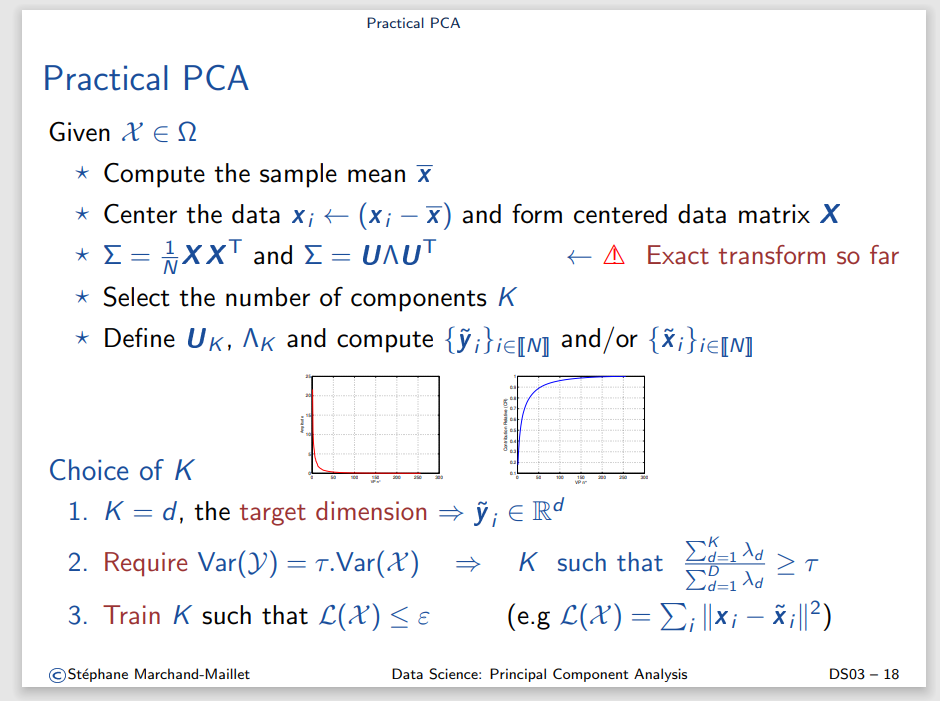

# Part 1: PCA calculation step by step

Step 1: Get your data

In [15]:
X = np.array([(2, 1), (3, 5), (4, 3), \
              (5, 6), (6, 7), (7, 8)])
X, X.shape

(array([[2, 1],
        [3, 5],
        [4, 3],
        [5, 6],
        [6, 7],
        [7, 8]]),
 (6, 2))

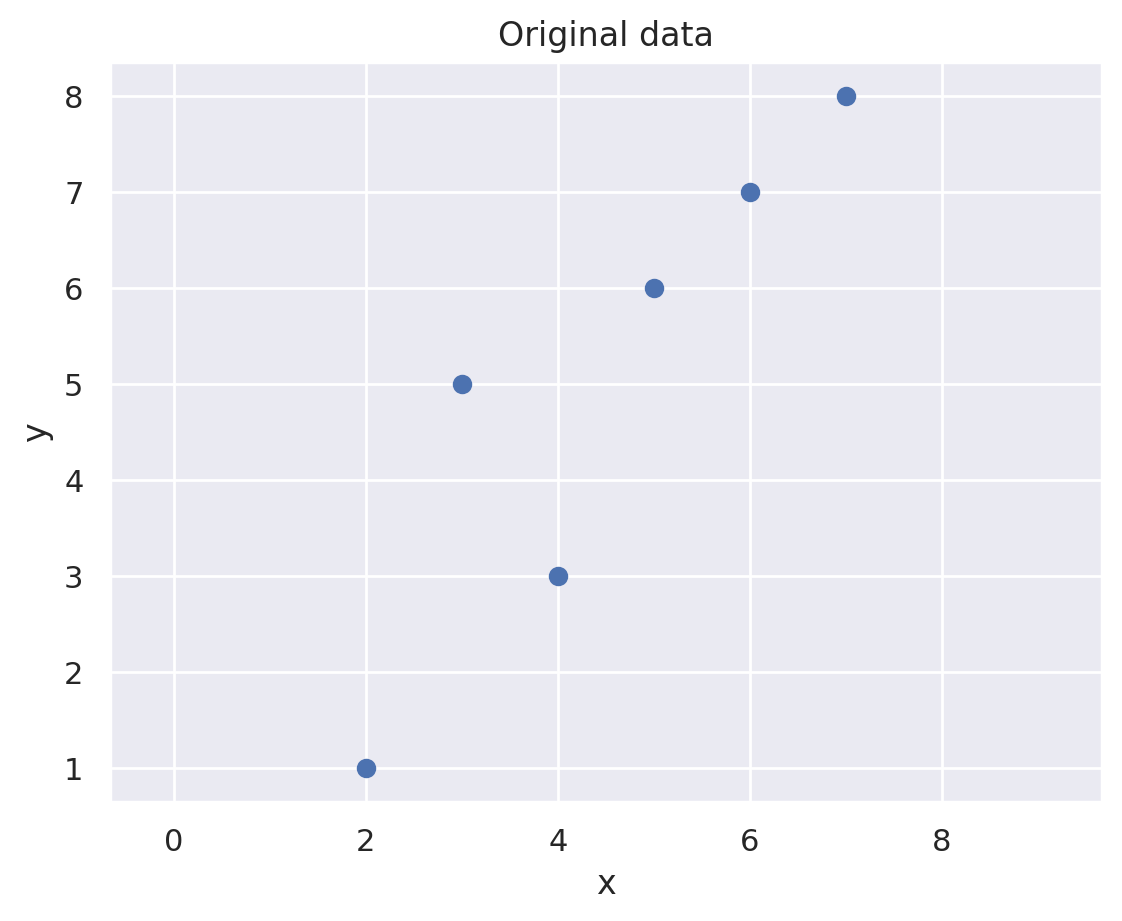

In [16]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original data")
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal');

Step 2: Center your data

In [17]:
mu =  np.mean(X, axis=0) # compute mean
mu

array([4.5, 5. ])

In [18]:
assert mu[1] == (1 + 5 + 3 + 6 + 7 + 8) / 6

In [19]:
A = X - mu# substract mean from data
A

array([[-2.5, -4. ],
       [-1.5,  0. ],
       [-0.5, -2. ],
       [ 0.5,  1. ],
       [ 1.5,  2. ],
       [ 2.5,  3. ]])

In [20]:
np.mean(A, axis=0)

array([0., 0.])

In [21]:
assert np.allclose(np.mean(A, axis=0), 0)

Step 3: Get Covariance of A

In [22]:
cov = 1 / (A.shape[0] - 1) * (A.T @ A)# compute covariance
print(np.cov(A.T))
cov

[[3.5 4.4]
 [4.4 6.8]]


array([[3.5, 4.4],
       [4.4, 6.8]])

In [23]:
assert cov.shape == (2, 2), 'covariance of two features should by 2x2 matrix'
assert np.all(np.linalg.eigvals(cov) >= 0) and np.array_equal(cov, cov.T), 'covariance should b positive semidefinite matrix'

Step 4: Calculate Eigen Vectors and Eigen Values

In [24]:
values, vectors = np.linalg.eig(cov)# find values and vectors

In [25]:
values

array([0.45079794, 9.84920206])

The second one should be much more important.

Step 5: Sort values and vectors descending

In [26]:
indices = np.argsort(values)[::-1]
values = values[indices]
vectors = vectors[:, indices]
values, vectors = values, vectors# sort by importance

Plot Explained Variance

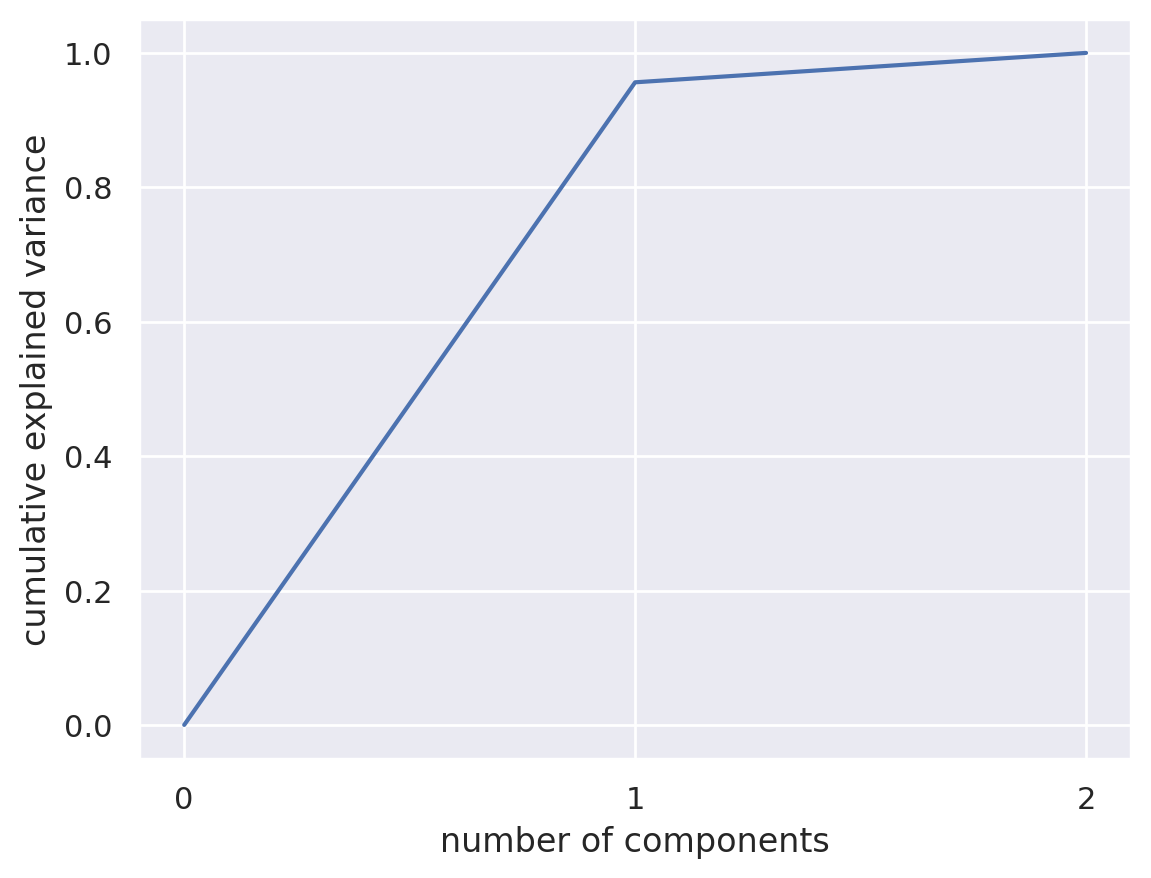

In [27]:
plt.plot(np.concatenate([[0], np.cumsum(values / values.sum())]))
plt.gca().xaxis.get_major_locator().set_params(integer=True)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Step 6: Calculate the transformation using all vectors initially

In [28]:
P = A @ vectors
P

array([[ 4.71168956, -0.22356531],
       [ 0.85439226,  1.23288843],
       [ 1.92864865, -0.72822687],
       [-1.10672304,  0.15863203],
       [-2.49824349, -0.09369875],
       [-3.88976395, -0.34602953]])

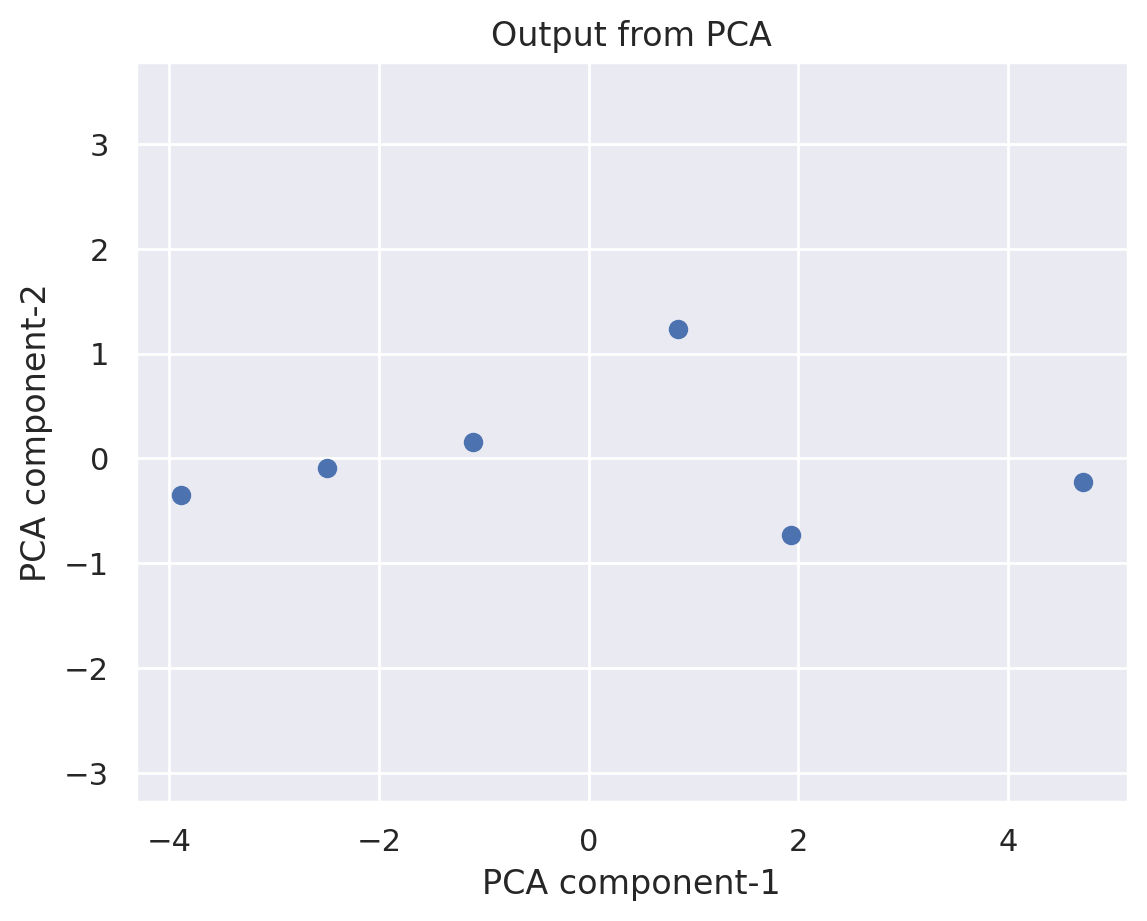

In [29]:
plt.scatter(P[:, 0], P[:, 1])
plt.title("Output from PCA")
plt.xlabel('PCA component-1')
plt.ylabel('PCA component-2')
plt.axis('equal');

Step 7: select only from the biggest eigen value

In [30]:
component_1 = P[:, 0].reshape(-1, 1)

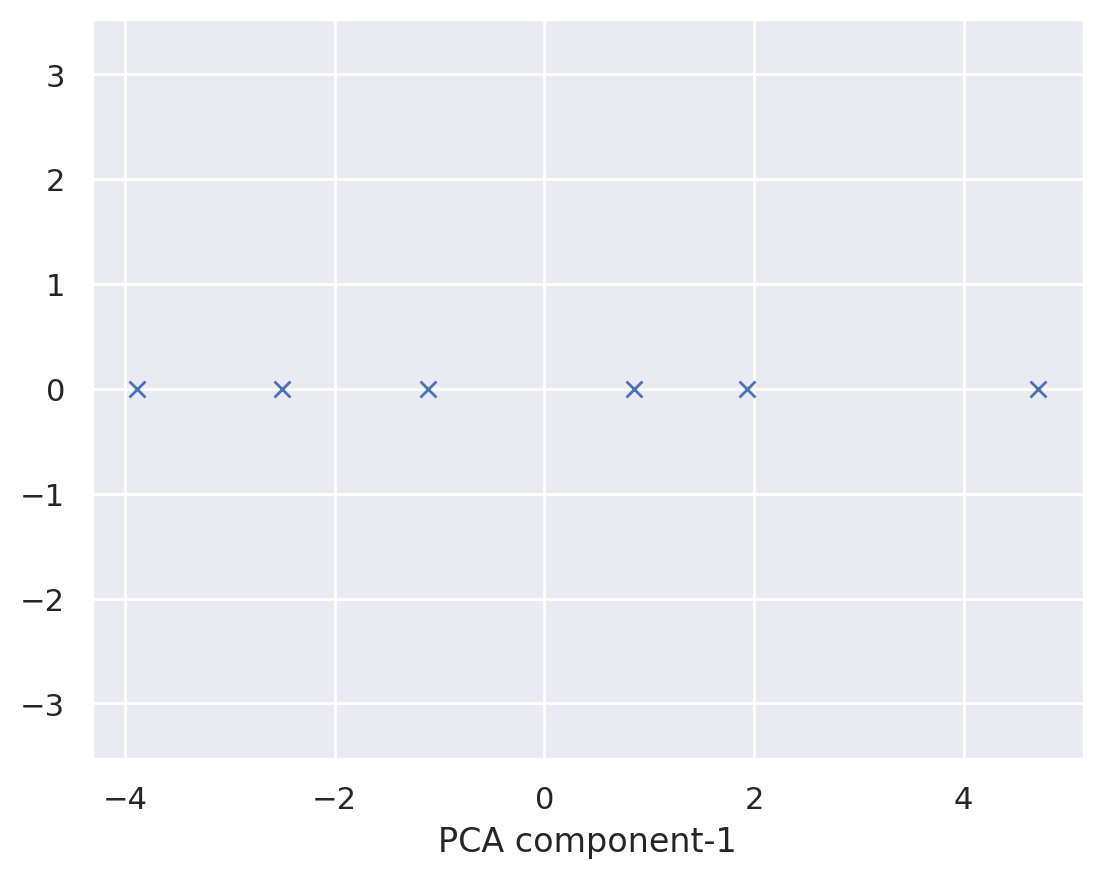

In [31]:
plt.plot(component_1, np.zeros_like(component_1), 'x')
plt.xlabel('PCA component-1')
plt.axis('equal');

Step 8: select only from the smallest eigen value (for debug only)

In [32]:
component_2 = P[:, 1].reshape(-1, 1)

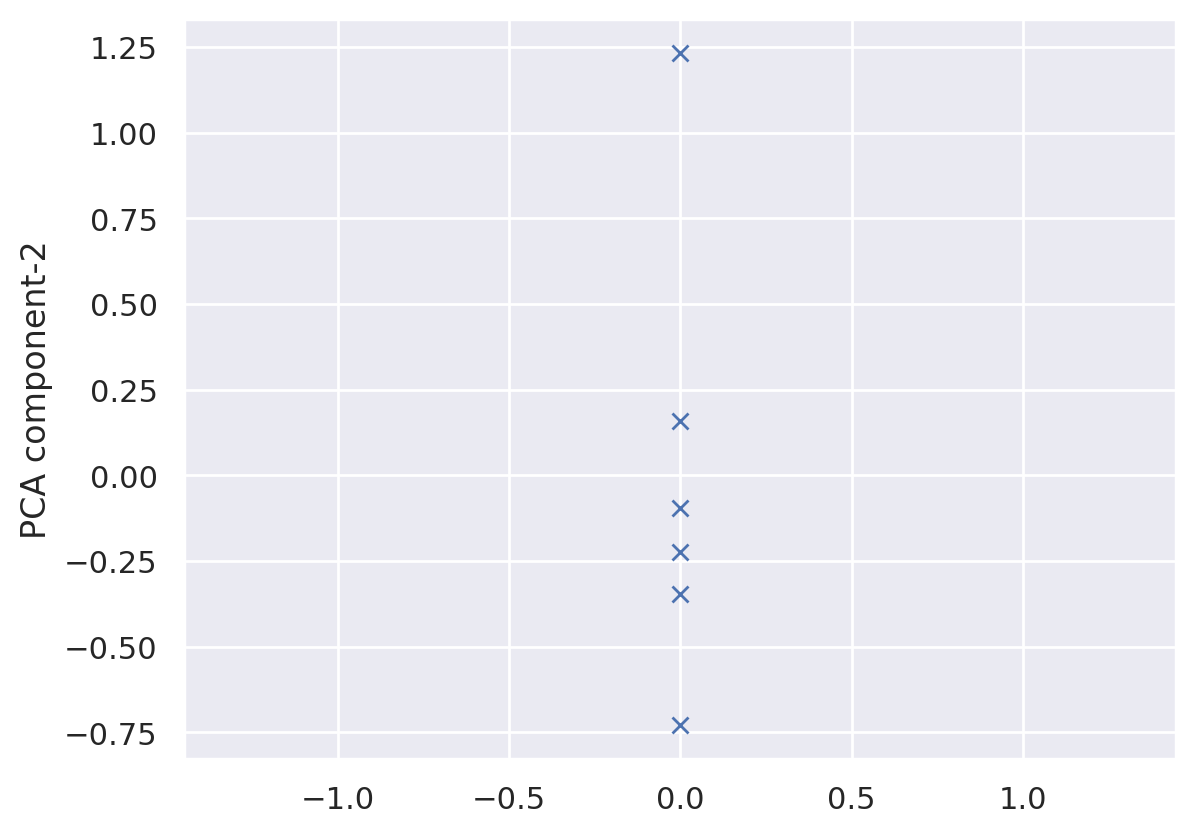

In [33]:
plt.plot(np.zeros_like(component_2), component_2, 'x')
plt.ylabel('PCA component-2')
plt.axis('equal');

### Compare with sklearn

In [34]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1, svd_solver='full')

In [35]:
pca.fit(X)

,n_components,1
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [36]:
pca.mean_

array([4.5, 5. ])

In [37]:
pca.get_covariance()

array([[3.5, 4.4],
       [4.4, 6.8]])

In [38]:
pca.transform(X)

array([[-4.71168956],
       [-0.85439226],
       [-1.92864865],
       [ 1.10672304],
       [ 2.49824349],
       [ 3.88976395]])

In [39]:
component_1

array([[ 4.71168956],
       [ 0.85439226],
       [ 1.92864865],
       [-1.10672304],
       [-2.49824349],
       [-3.88976395]])

In [40]:
assert np.allclose(pca.mean_, mu)
assert np.allclose(pca.get_covariance(), cov)
# sklearn can flip the axis, so it will be negative
# but we are not interested in the direction, only transformation
assert np.allclose(abs(pca.transform(X) / component_1), 1)

They are the same!

### Conclusion of the first part

To compute PCA you need to do the following:
* Compute the mean for every dimension of the whole dataet.
* Compute the covariance matrix of the whole dataet.
* Compute eigenvectors and the corresponding eigenvalues.
* Sort the eigenvectors by decreasing eigenvalues and choose k eigenvectors with the largest eigenvalues to form a d × k dimensional matrix W.
* Use this d × k eigenvector matrix to transform the samples onto the new subspace.

[nice explanation](https://sebastianraschka.com/Articles/2015_pca_in_3_steps.html)

[source](https://towardsdatacience.com/the-mathematics-behind-principal-component-analysis-fff2d7f4b643)

Steps from [here](https://iq.opengenus.org/algorithm-principal-component-analysis-pca/)

Or you can just use `sklearn` library (much cleaner, faster, ...)

# Part 2: PCA calculation via single class

You've successfully implemented PCA calculation step-by-step. Congratulations!

Now you need to combine your solution in a single class, based on `sklearn` interface. To know more about the interface refer to the [documentation](https://scikit-learn.org/stable/developers/develop.html#rolling-your-own-estimator).

In this section you need to implement `__init__`, `fit`, `transform` and `inverse_transform` methods.

Then you need to launch the next cell to test correctness of your class.

In [41]:
from sklearn.base import TransformerMixin, BaseEstimator

In [42]:
class CustomPCA(TransformerMixin, BaseEstimator):
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.values = None
        self.vectors = None
        self.X = None

    def fit(self, X):
        """
        Fit the model with X.
        """
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        cov = np.cov(X_centered.T).astype(np.float64)
        # self.vectors, self.values, _ = np.linalg.svd(cov, hermitian=True)
        self.values, self.vectors = np.linalg.eig(cov)
        indices = np.argsort(self.values)[::-1]
        self.values = self.values[indices[:self.n_components]]
        self.vectors = self.vectors[:, indices[:self.n_components]]
        return self

    def transform(self, X):
        """
        Apply dimensionality reduction to X.
        """
        X_centered = X - self.mean
        return X_centered @ self.vectors

    def inverse_transform(self, X):
        """
        Transform data back to its original space.
        """
        return X @ self.vectors.T + self.mean

In [43]:
### some utility code ###

SAMPLES_MIN, SAMPLES_MAX = 5, 10000
FEATURES_MIN, FEATURES_MAX = 2, 300
def generate_random_matrix(rng, n_samples=None, n_features=None):
    if n_samples is None:
        n_samples = rng.randint(SAMPLES_MIN, SAMPLES_MAX + 1)
    if n_features is None:
        n_features = rng.randint(FEATURES_MIN, FEATURES_MAX + 1)
    random_type = rng.randint(2)
    if random_type == 0:
        # uniform distribution
        low, high = rng.rand(2) * 100
        low, high = min(low, high), max(low, high)
        return rng.uniform(low, high, (n_samples, n_features)).astype(np.float64)
    # normal distribution
    loc, scale = rng.rand(2) * 100
    return rng.normal(loc, scale, (n_samples, n_features)).astype(np.float64)


def check_pca(X, custom_pca, sklearn_pca, matrix_name=''):
    custom_transform = custom_pca.transform(X)
    sklearn_transform = sklearn_pca.transform(X)

    assert np.all(np.isclose(custom_transform - sklearn_transform, 0) | np.isclose(custom_transform + sklearn_transform, 0)), f'pca transform does not equal with sklearn for {matrix_name} matrix'

    custom_inverse_transform = custom_pca.inverse_transform(custom_transform)
    sklearn_inverse_transform = sklearn_pca.inverse_transform(sklearn_transform)

    assert np.allclose(custom_inverse_transform, sklearn_inverse_transform), f'pca inverse transform does not equal with sklearn for {matrix_name} matrix'

In [44]:
%%time
rng = np.random.RandomState(42)
N_RETRIES = 20
N_DIFFERENT_COMPONENTS = 2
N_DIFFERENT_MATRICIES = 2

for _ in trange(N_RETRIES):
    X = generate_random_matrix(rng)
    n_samples, n_features = X.shape

    for n_components in rng.choice(range(1, n_features + 1), min(N_DIFFERENT_COMPONENTS, n_features), replace=False):
        custom_pca = CustomPCA(n_components=n_components).fit(X)
        sklearn_pca = PCA(n_components=n_components, svd_solver='full').fit(X)

        check_pca(X, custom_pca, sklearn_pca, 'original')

        for _ in range(N_DIFFERENT_MATRICIES):
            Y = generate_random_matrix(rng, n_features=n_features)
            check_pca(Y, custom_pca, sklearn_pca, 'different')

100%|██████████| 20/20 [00:18<00:00,  1.06it/s]

CPU times: user 1min 49s, sys: 1.1 s, total: 1min 50s
Wall time: 18.8 s


# Part 3 (optional, winner get 1 bonus pt): speed up PCA calculation.

Aim for time less then 34s.

Rules:
* You can not modify data generation
* You can not modify testing script
* Your results should be correct everytime (comparing to sklearn)
* You can not use any global variables
* You can edit only your class
* You can use any library already installed in Colab
* You can not upgrade/downgrade any library
* You can do warm-up and/or compilation before

In [58]:
import scipy as sp

class FastCustomPCA(CustomPCA):
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.values = None
        self.vectors = None

    def fit(self, X):
        """
        Fit the model with X.
        """
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        cov = 1 / (X_centered.shape[0] - 1) * X_centered.T @ X_centered
        self.values, self.vectors = sp.sparse.linalg.eigsh(cov, k=self.n_components, which="LM")
        self.values = self.values[::-1]
        self.vectors = self.vectors[:, ::-1]
        return self

    def transform(self, X):
        """
        Apply dimensionality reduction to X.
        """
        X_centered = X - self.mean
        return X_centered @ self.vectors

    def inverse_transform(self, X):
        """
        Transform data back to its original space.
        """
        return X @ self.vectors.T + self.mean

In [46]:
%%time
### DO NOT MODIFY ###

# %%time
rng = np.random.RandomState(42)
N_RETRIES = 20
N_DIFFERENT_COMPONENTS = 2
N_DIFFERENT_MATRICIES = 2

for _ in trange(N_RETRIES):
    X = generate_random_matrix(rng)
    n_samples, n_features = X.shape

    for n_components in rng.choice(range(1, n_features + 1), min(N_DIFFERENT_COMPONENTS, n_features), replace=False):
        custom_pca = FastCustomPCA(n_components=n_components).fit(X)
        sklearn_pca = PCA(n_components=n_components, svd_solver='full').fit(X)

        check_pca(X, custom_pca, sklearn_pca, 'original')

        for _ in range(N_DIFFERENT_MATRICIES):
            Y = generate_random_matrix(rng, n_features=n_features)
            check_pca(Y, custom_pca, sklearn_pca, 'different')

100%|██████████| 20/20 [00:16<00:00,  1.21it/s]

CPU times: user 1min 33s, sys: 903 ms, total: 1min 34s
Wall time: 16.5 s


# Exercice 2
Randomly sample 5000 images of the digit $2$ from the MNIST dataet. Denote this subset as $\mathcal{X} = \{x_i\}_{i=1}^n$, where each $x_i$ is a 784-dimensional vector corresponding to a $28 \times 28$ image of the digit $2$, and $n = 5000$. Perform PCA on $\mathcal{X}$. Denote the first m ($1 \leq m \leq 784$) principal components (with the largest variance) of $\mathcal{X}$ as $\{PC_1, \ldots, PC_m\}$. Note, that each $PC_j$ is also a 784-dimensional vector.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

images, labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, random_state=42)

In [ ]:
def select_with_label(images, labels, desired_labels):
    mask = np.isin(labels, desired_labels)
    return images[mask], labels[mask]

images_of_two, labels_of_two = select_with_label(train_images, train_labels, desired_labels=['2'])
images_of_odd, labels_of_odd = select_with_label(train_images, train_labels, desired_labels=['1', '3', '5', '7', '9'])

sample_index = np.random.choice(np.arange(images_of_two.shape[0]), size=5000, replace=False).astype(int)
sample_index_two = np.random.choice(np.arange(images_of_two.shape[0]), size=5, replace=False).astype(int)
sample_images = images_of_two[sample_index, :]
sample_labels = labels_of_two[sample_index]
sample_images_of_two = images_of_two[sample_index_two]
sample_labels_of_two = labels_of_two[sample_index_two]
assert sample_images.shape[0] == 5000, f"Number of sample must be 5000 ! Actual: {sample_images.shape[0]}"

1. Centering vs standardization: Do you need to _center_ the data (subtract the mean) and/or _standardize_ (scale to unit variance) before PCA? Why or why not? Support your answer using formulas and a small sketch. Also discuss specifically for MNIST dataet.

#### Is centrification of data useful ?

PCA look at the variance of the data because the variance measure the quantity of information.
PCA will try to maximise the variance on each axis because the variance maximisation is equivalent to error minimisation.

For instance, to get an overview of what's happen, assuming we have our new dimension found by maximisation of variance.
The projection of a data $x$ on our new dimension will give us a new data $\hat{x}$ on the new dimension.
The variance will be the range where all the $x_i$ will be projected.
If we represent the variance like an edge of a rectangle triange, and the error $x - \hat{x}$ like another edge, we have according to Pythagore that the hypotenuse is equal to $variance^2$ + $error^2$. So if we maximise the $variance$, we minimise the $error$.

The variance is given by the following formula for $X$:

$$
Var(X) = \mathbf{E}\left[(X - \mathbf{E}[X])^2\right]
$$ {#eq-test}

So in the formula of the variance, we center the data $X$ by subtracting the mean $\mathbf{E}[X]$.

However, PCA works with covariance matrix, which is a multidimensional generalisation of the variance.

The covariance matrix of the data centered $X$ is given by the following formula:

$$
Cov(X, X) = 
\begin{pmatrix}
X_{1}^2 & \cdots & X_{1}X_{n} \\
\vdots & \ddots & \vdots \\
X_{1}X_{n} & \cdots & X_{n}^2
\end{pmatrix}
$$

In this formula, it's easy to see that if $X$ is centered, we have on the diagonal $X_i^2 = (X_i - \underbrace{\mathbf{E}[X_i]}_{= \ 0})^2 = Var(X_i)$. (That's why it's a generalisation of the variance on multidimensions...)

Then, PCA performs an Eigen Value Decomposition (EVD) on the covariance matrix to find greater eigenvalues.

Suppose that we have not centered our data.
So $X = \hat{X} + \mu$ with $\mu$ the mean of $X$ and $\hat{X}$ the centered data.
We have our covariance given by:

$$
Cov(X, X) = 
\begin{pmatrix}
(\hat{X}_{1} + \mu_1)^2 & \cdots & (\hat{X}_{1} + \mu_1)(\hat{X}_{n} + \mu_n) \\
\vdots & \ddots & \vdots \\
(\hat{X}_{1} + \mu_1)(\hat{X}_{n} + \mu_n) & \cdots & (\hat{X}_{n} + \mu_n)^2
\end{pmatrix}
$$

For instance, if $\mu_n$ is very big and $\mu_1$ is very small, our covariance matrix will be very different, that give us a different EVD of our matrix, with not the same eigen values and eigen vectors.
It will give us an other PCA transfom that doesn't maximise the variance because the PCA is distorted by the mean.
In fact, as the covariance assumes that the data are centered, if we compute the PCA on data not centered in covariance matrix, we compute PCA for a falsified covariance, or for another set of data...

So as we are working with the variance, it's very useful to center data to avoid an influence of the mean that causes a bias in the result due to the mean.

#### Is standardisation useful ?

Yes, in some case, standardisation is useful...
Sometimes, we works on data with real scale (like meters, centimeters, kilometers, etc...).
For instance, suppose that we don't have the same scales on our data.
PCA could choose for instance the feature $A$ as the feature that have the greatest variance.
However feature $A$ is in meters, whereas feature $B$ has a variance a little smaller, but in kilometers.
So if we had standardised our data, the variance of the feature $B$ will be choosen instead of the feature $A$ that is very small compared to the feature $B$ after standardisation.

So sometimes, it's useful to apply a standardisation of the data before PCA.

2. Plot the sorted eigenvalues (descending) of the covariance matrix. Label axes clearly.

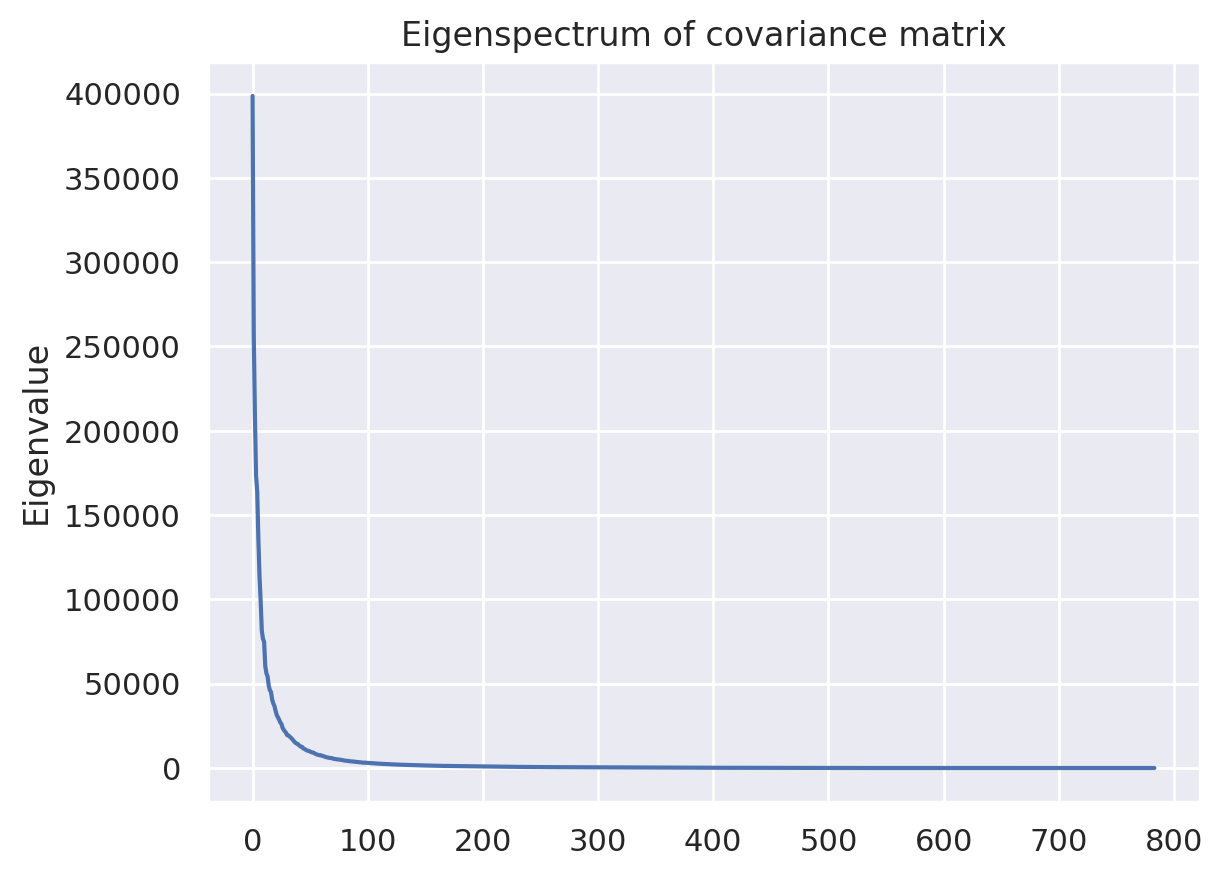

In [ ]:
cov = np.cov(sample_images.T)
# Using svd instead of eig give eigen values sorted in decreasing order
# No need to make it manualy
eigenvector, eigenvalues, _ = np.linalg.svd(cov)

plt.figure()
plt.plot(np.arange(len(eigenvalues)), eigenvalues)
plt.title("Eigenspectrum of covariance matrix")
plt.ylabel("Eigenvalue")
plt.show()

3. Plot the cumulative explained variance as a function of the number of components $k$: $\sum_{j=1}^k \lambda_j / \sum_{j=1}^{784} \lambda_j$, where $\lambda_j$ are eigenvalues sorted in descending order.

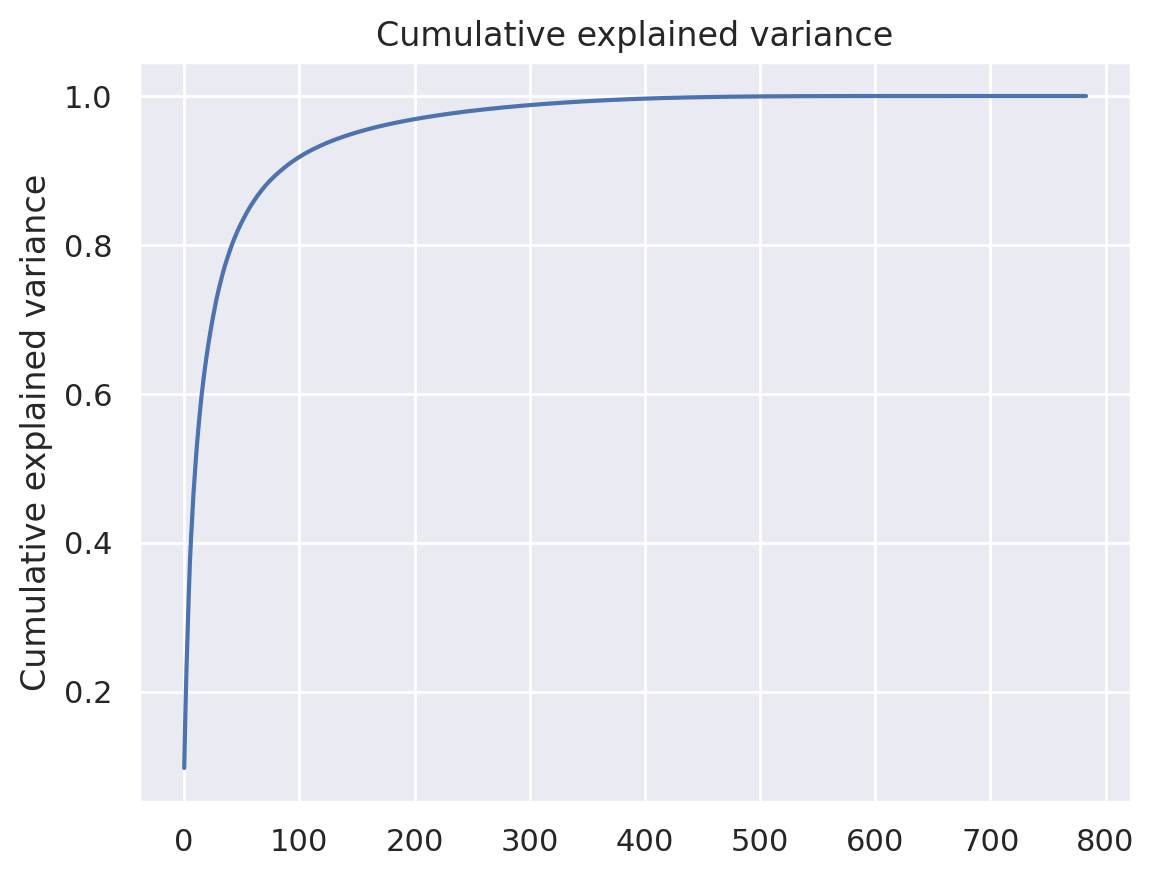

In [ ]:
cumulative_explained_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

plt.figure()
plt.plot(np.arange(len(cumulative_explained_variance)), cumulative_explained_variance)
plt.title("Cumulative explained variance")
plt.ylabel("Cumulative explained variance")
plt.show()

4. Any image $x_i \in \mathcal{X}$ can be reconstructed using $\{PC_1, \ldots, PC_m\}$ by
    $$r_m(x_i) = \sum_{j=1}^m \langle x_i - \bar{x}, PC_j \rangle \cdot PC_j + \bar{x}$$
    where $\bar{x} = \frac 1n \sum\limits_{i=1}^{n} x_i$ is the average image and $\langle \cdot, \cdot \rangle$ denotes the inner product. The corresponding reconstruction error of $\mathcal{X}$ (using the Euclidean norm) is
    $$err(\mathcal{X}, m) = \frac{1}{n} \sum\limits_{i=1}^{n} \lVert x_i - r_m(x_i) \rVert_2.$$
    
    - Plot $err(\mathcal{X}, m)$ as a function of $m$ for $m = 0, 1, \ldots, 784$ (include $m=0$ as the baseline, which yields $r_0(x_i) = \bar{x}$).
    - Define the relative error $\mathrm{RE}(m) = err(\mathcal{X}, m) / \max_{k} err(\mathcal{X}, k)$. Find the smallest $m$ such that $\mathrm{RE}(m) \leq 0.50$, $\mathrm{RE}(m) \leq 0.05$, and $\mathrm{RE}(m) \leq 0.01$ (i.e., $50\%$, $95\%$, and $99\%$ reduction relative to the maximum error).

In [ ]:
def reconstruct(X: np.ndarray, PC: np.ndarray, m: int) -> np.ndarray:
    mean = np.mean(X, axis=0)
    return ((X - mean) @ PC[:, :m]) @ PC[:, :m].T + mean

def err(X: np.ndarray, PC: np.ndarray, m: int) -> float:
    return np.mean(np.linalg.norm(X - reconstruct(X, PC, m)))

error = np.array([err(sample_images, eigenvector, m) for m in range(785)])
m = np.arange(785)

KeyboardInterrupt: 

In [ ]:
plt.figure()
plt.plot(m, error)
plt.title("Mean Squared Error for m features")
plt.xlabel("Number of features kept")
plt.ylabel("Mean Squared Error")
plt.show()

RE = error / max(error)
m_05 = m[RE <= 0.5][0]
m_005 = m[RE <= 0.05][0]
m_001 = m[RE <= 0.01][0]
m_list = [m_05, m_005, m_001]
plt.figure()
plt.plot(m, error / max(error))
for k in m_list:
    plt.plot(k, RE[k], 'ro')
    plt.plot([k, k], [0, RE[k]], '--', color='gray')
    # Annotate x value below x-axis
    plt.annotate(f"m={k}", xy=(k, 0), xytext=(0, 0),
                 textcoords='offset points', ha='center', va='top',
                 fontsize=9, color='blue')
plt.plot(m, 0.5 * np.ones_like(m), label="0.5")
plt.plot(m, 0.05 * np.ones_like(m), label="0.05")
plt.plot(m, 0.01 * np.ones_like(m), label="0.01")
plt.title("Relative Error for m features")
plt.xlabel("Number of features kept")
plt.ylabel("Relative Error")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.show()


NameError: name 'error' is not defined

<Figure size 640x480 with 0 Axes>

5. Compare the three plots (eigenvalues, cumulative explained variance, and reconstruction error). What relationships do you observe?

First, to simplify the comparison, when I say that we keep only the first eigenvalues, it means that we keep also the first eigenvectors used for the transformation.

Recall: the transformation is given by $y = U^Tx$ for $U$ the eigenvector of the covariance matrix.

On the graph that represent eigenvalues, we can see that the eigenvalues decrease exponentialy.
The first eigenvalues have huge values, and then it decreases fastly around 0.

If we look at the cumulative explained variance, we can see that it increases very fastly and then stage around 1.
It's normal because the eigenvalues are concentrated in the first components, and the cumulative explained variance is obtained by the formula below:
$$\text{cumulative explained variance} = \sum_{j=1}^k \lambda_j / \sum_{j=1}^{784} \lambda_j$$
with $\lambda_j$ the eigenvalue $j$.
So as the first eigenvalues are big, the sum increase quickly and then, as the other eigenvalues are closest to 0, the sum stage around 1.
The quantity of information is represented by the variance for a given set of data.
So when we look at the cumulative explained variance graph, we can see that for each corresponding eigenvalues kept, the variance increase fastly.
So the quantity of informations is captured mostly by the first eigenvalues.

Finaly, the plot of the reconstruction error follow the eigenvalue plot, but not with the same range.
This plot means that when we take only the first $m$ dimensions of our transformed data, we can reconstruct the original data with a MSE as shown in the plot, depending on the number of dimensions kept.
The interesting thing here is that we can see that with only $m = 600$ dimensions, we can reconstruct our data with a $MSE$ closest to $0$.
So all the dimensions are not useful in the set of data, that's why we can decrease the number of dimensions of our data to simplify next computations.

If we link this plot to the plot of the eigenspectrum and the cumulative explained variance, it means that it's possible to decrease the number of dimensions of a dataset without a big loss of informations by keeping the first eigenvalues, because the information is concentrated in the first components.

6. Plot the mean vector of $\mathcal{X}$ and the first $10$ principal components as $28\times 28$ images (and not 1D vectors).

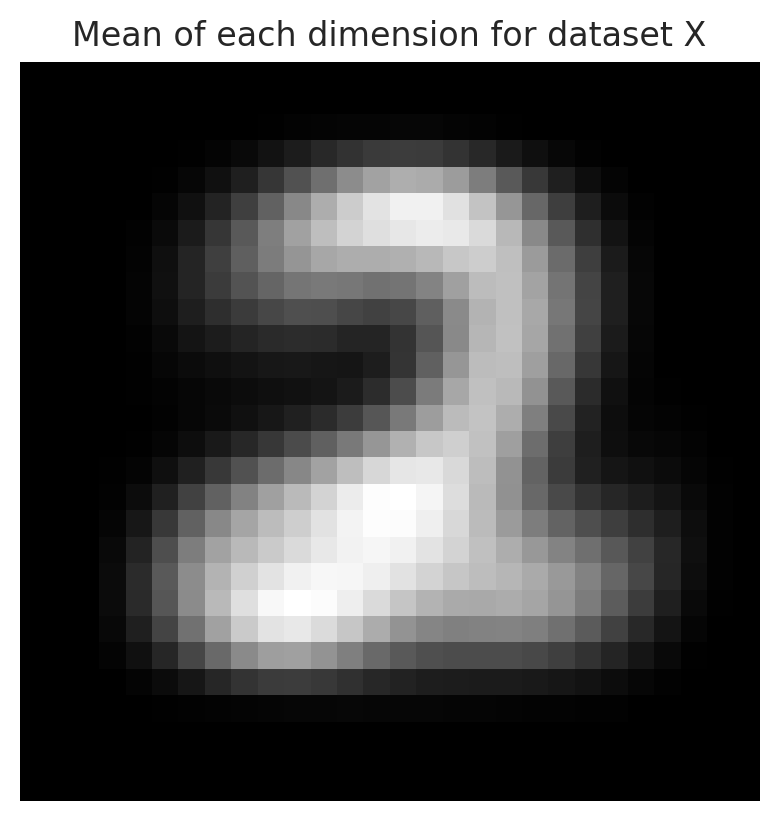

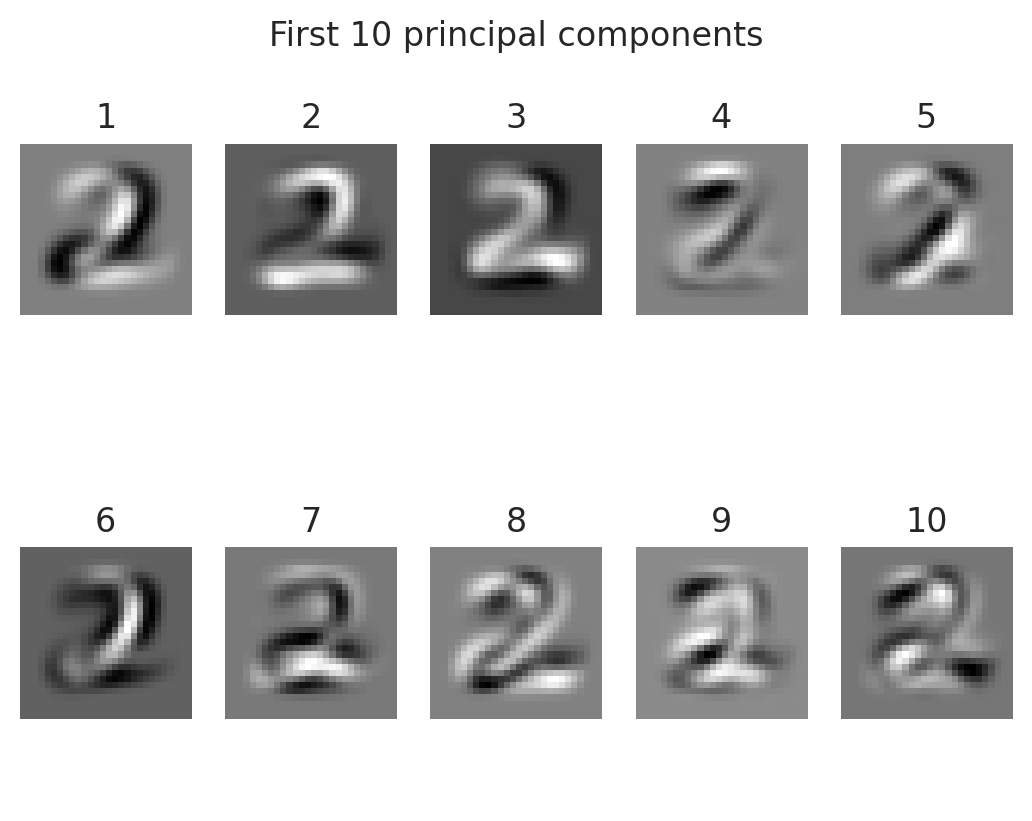

In [ ]:
mean = np.mean(sample_images, axis=0)
plt.figure()
plt.imshow(mean.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.title("Mean of each dimension for dataset X")
plt.xlabel("Dimension")
plt.ylabel("Mean")
plt.show()

plt.figure()
plt.title("First 10 principal components")
plt.axis('off')
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(eigenvector[:, i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"{i + 1}")
plt.show()


7. Sample $5$ random images of digit $2$ from MNIST (outside of $\mathcal{X}$; use a held-out set). For each image $\mathcal{I}$ and for each $m = 1, 2, \ldots, 10$ do:

    - Compute the reconstruction of $\mathcal{I}$ using the first $m$ principal components of $\mathcal{X}$
    - Calculate the reconstruction loss $\lVert \mathcal{I} - r_m(\mathcal{I}) \rVert_2$ for each image and each $m$ (round the loss values to two decimal places).

    In total, you should have $50$ reconstructed images and $5$ original images. Plot these images in a grid/table (e.g., columns: $\textit{original image, reconstructions for $m = 1, 2, \ldots, 10$}$) Don't forget to add reconstruction loss.

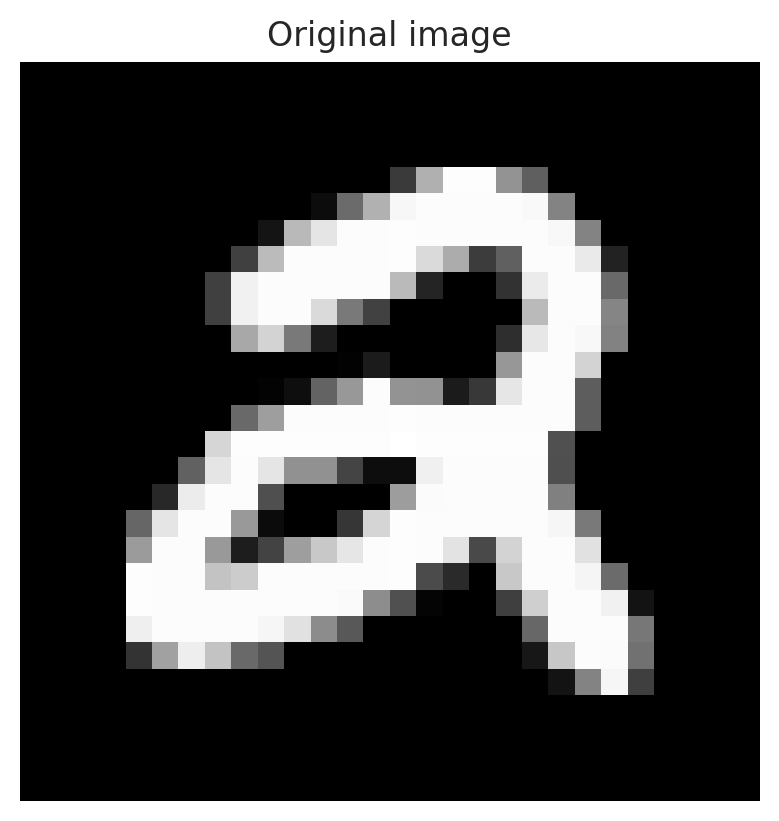

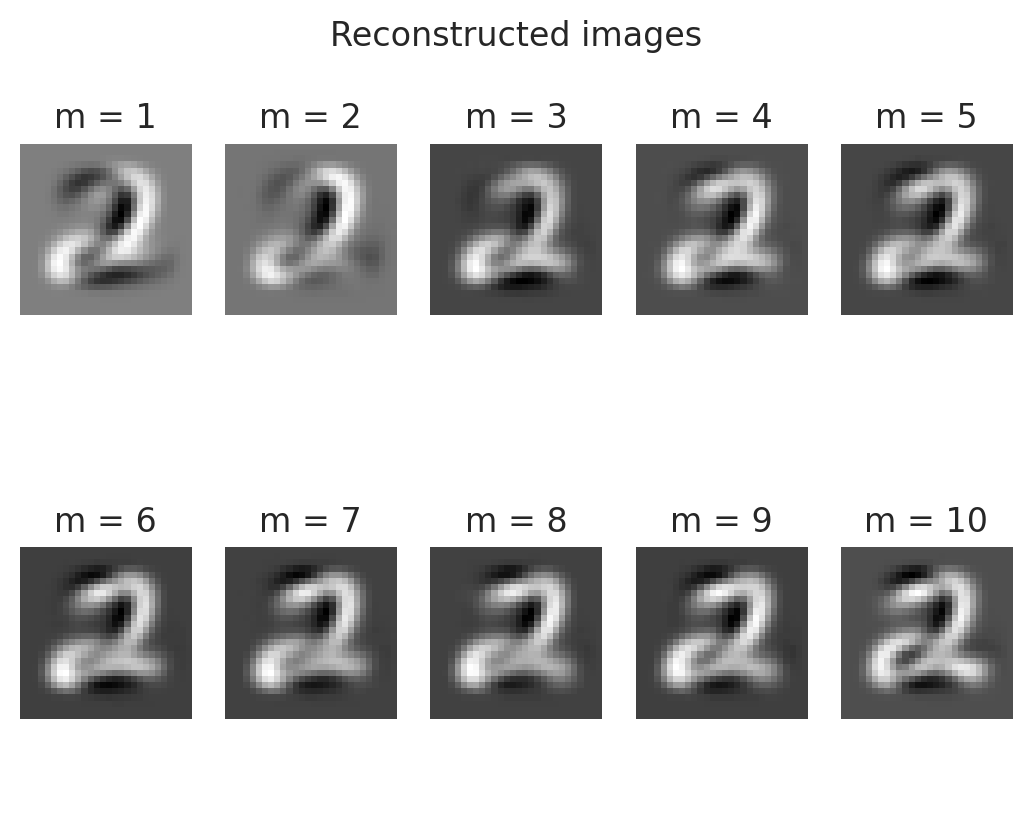

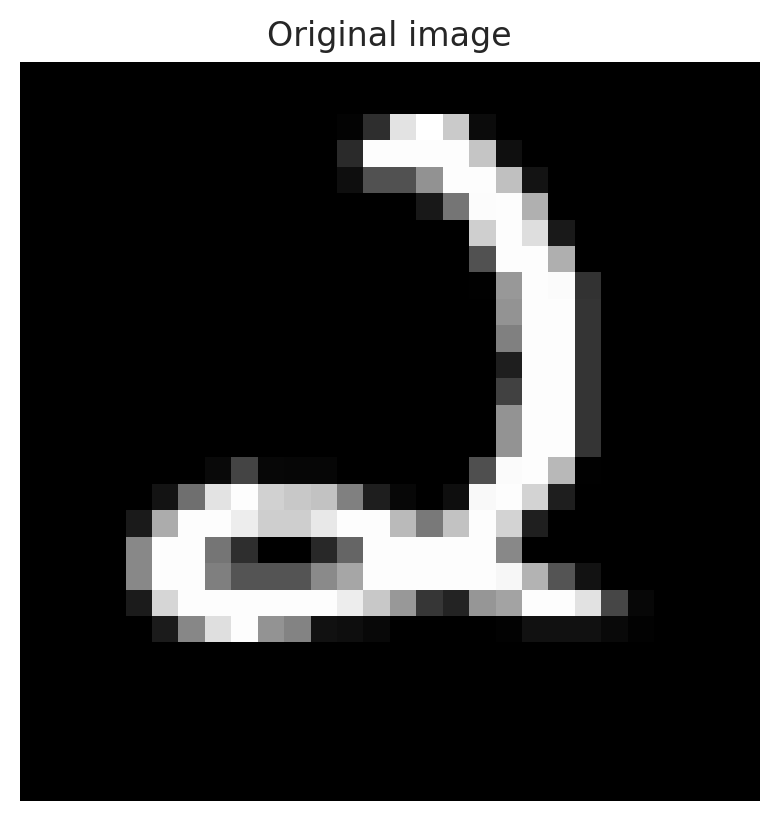

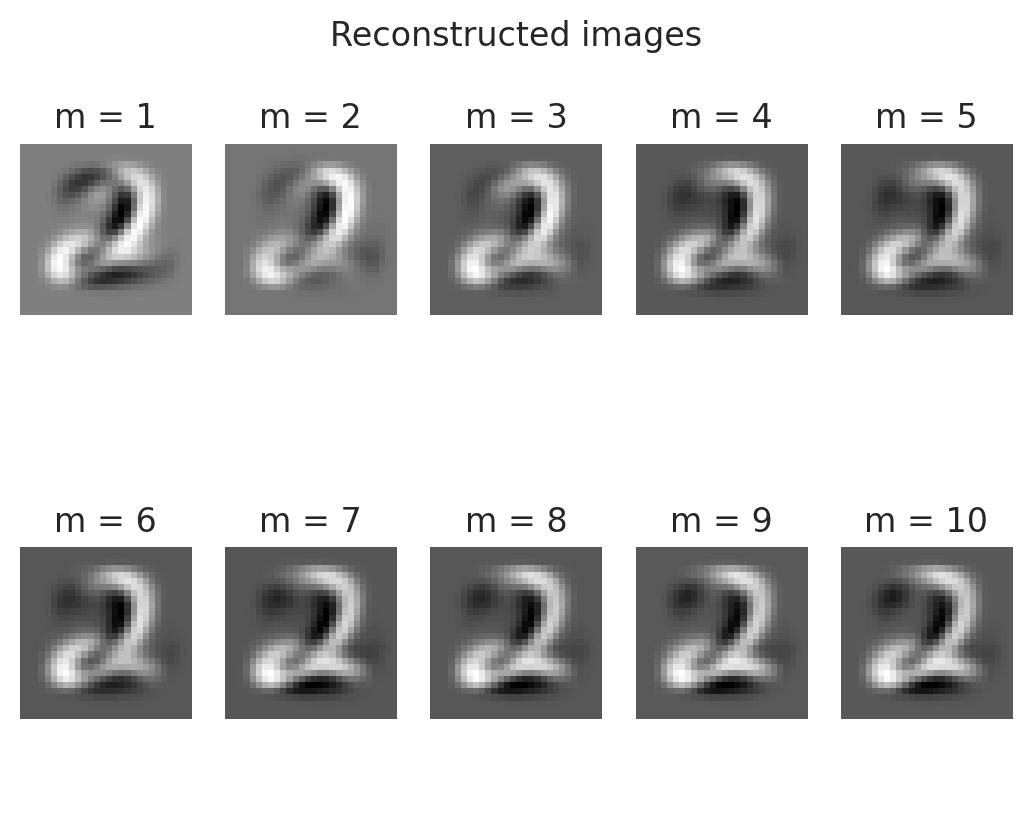

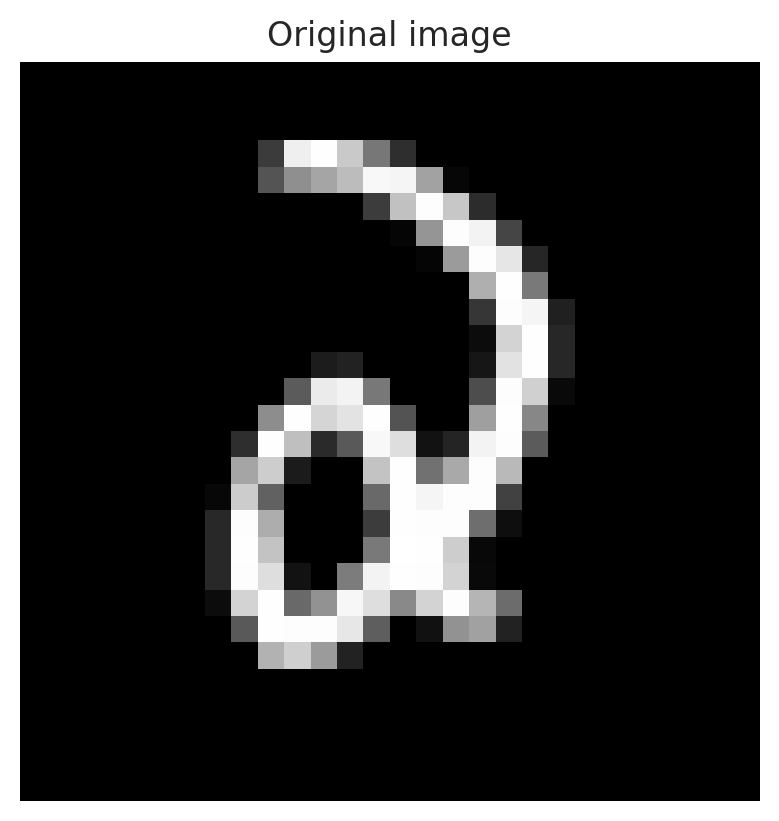

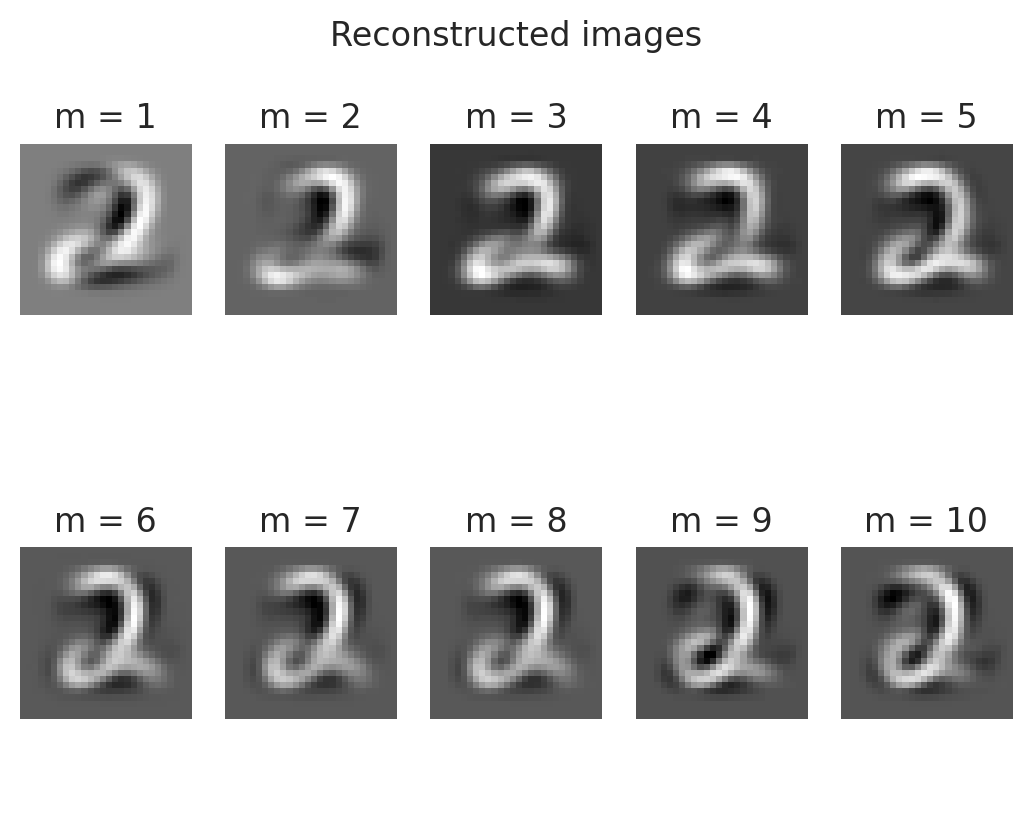

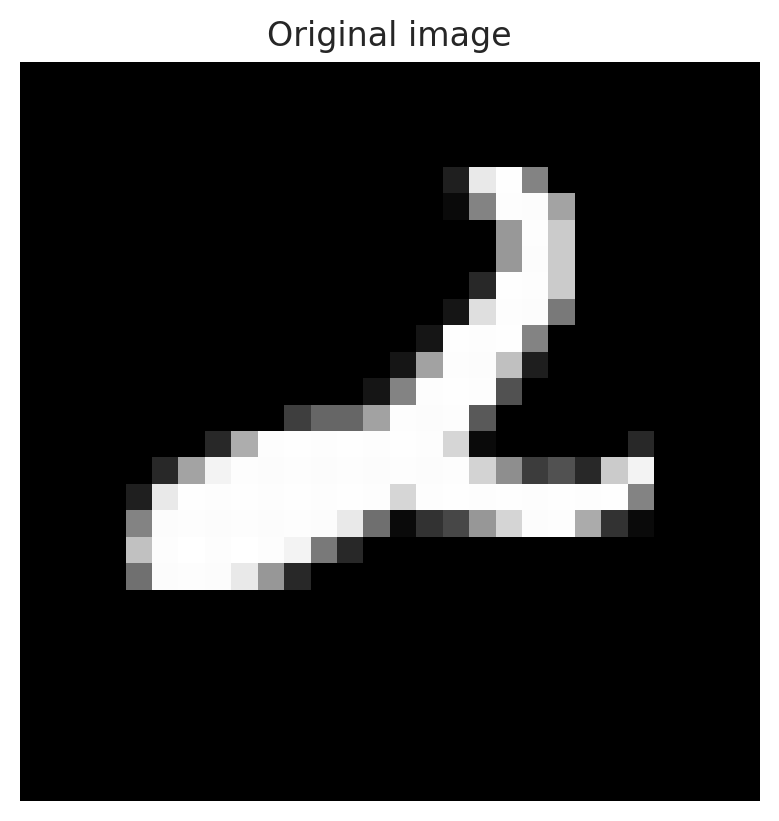

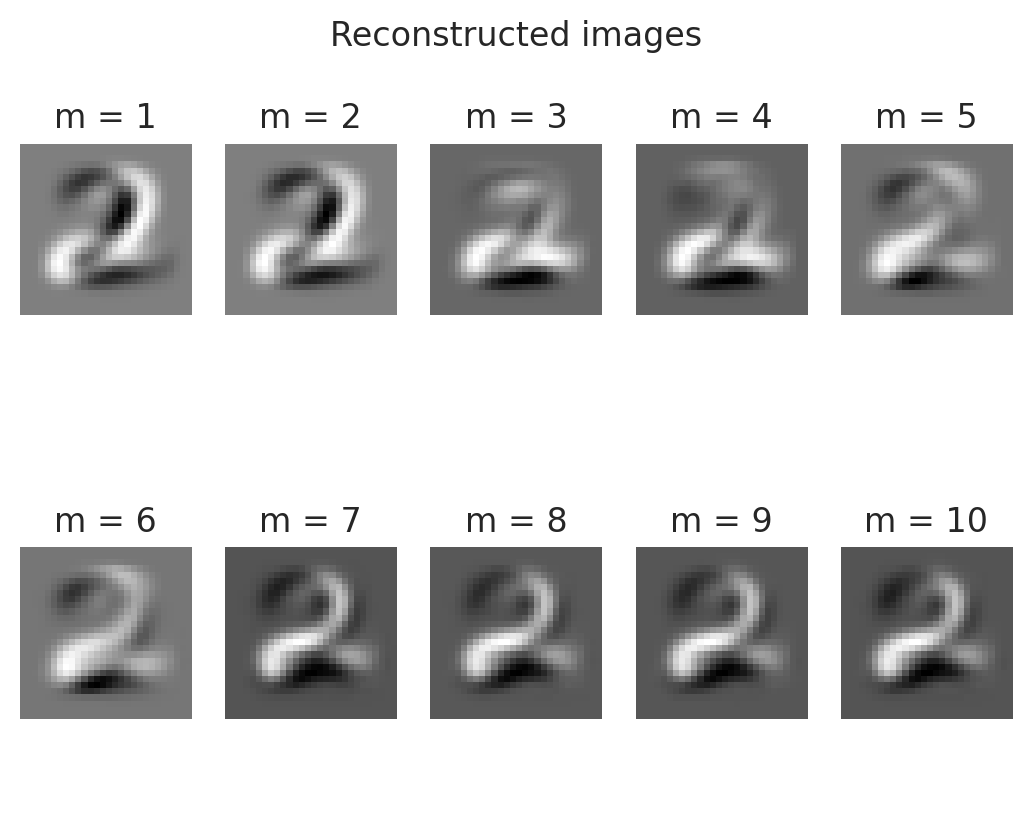

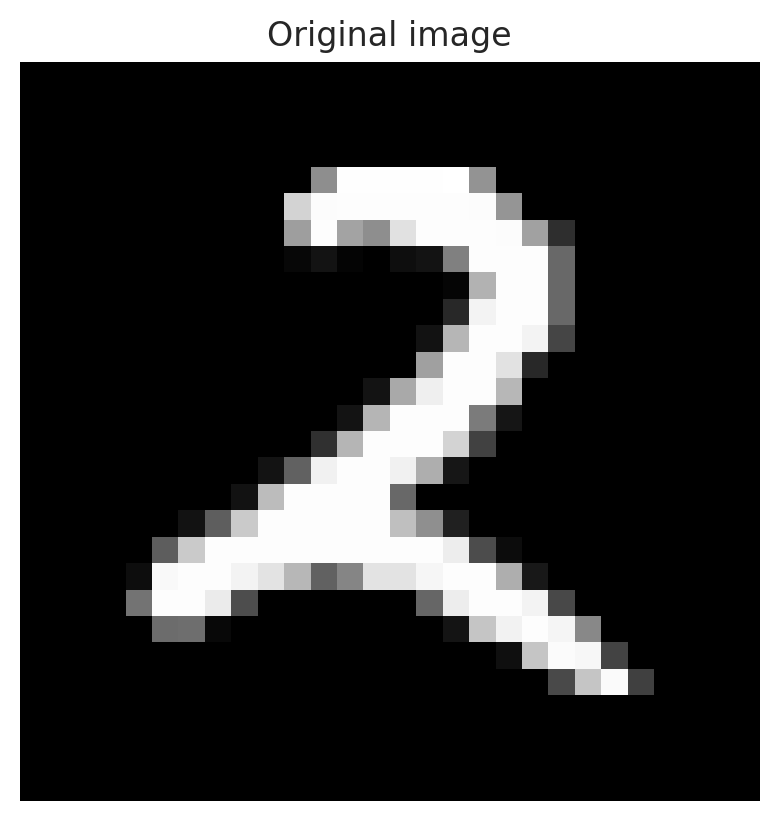

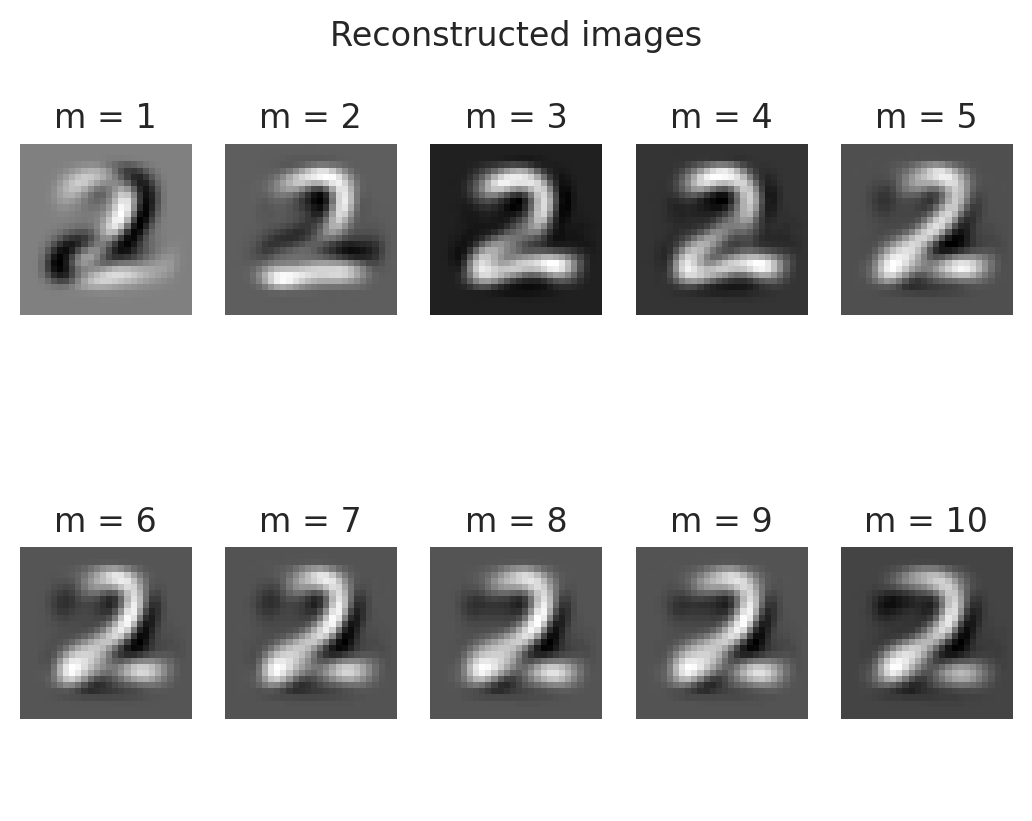

In [ ]:
# cov = np.cov(sample_images_of_two.T)
# vectors, values, _ = np.linalg.svd(cov)


for i in range(len(sample_images_of_two)):
    plt.figure()
    plt.imshow(sample_images_of_two[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title("Original image")
    plt.show()

    plt.figure()
    plt.title("Reconstructed images")
    plt.axis('off')
    for m in range(1, 11):
        plt.subplot(2, 5, m)
        plt.imshow(reconstruct(sample_images_of_two[i], eigenvector, m).reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"m = {m}")
    plt.show()

    

# Exercice 3: $\textit{k}$-Nearest-Neighbour ($\textit{k}$-NN) Classification

Randomly sample a *balanced* training set of $5000$ images from the digits “0”, “1”, “2”, “3”, and “4” ($1000$ per class). For the testing set, use all available testing images of the same classes. Record the random seed you used.

The main idea of $\textit{1}$-NN classifier is:

> To classify a sample $x$ in the testing set, select the nearest sample from $\mathcal{X}$ in the *training set*, then predict the class label of $x$ to be the same as this nearest sample.



To generalize this idea to $\textit{k}$-NN classifier you need to select $\textit{k}$ nearest samples instead of only one.

In [48]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

images, labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, random_state=42)

In [49]:
# Prepare data
def select_with_label(images, labels, desired_labels):
    mask = np.isin(labels, desired_labels)
    return images[mask], labels[mask]

train, labels = select_with_label(train_images, train_labels, desired_labels=['0', '1', '2', '3', '4'])

X_train, X_test, y_train, y_test = train_test_split(train, labels, train_size=5000, stratify=labels)

assert X_train.shape[0] == 5000, f"Number of sample must be 5000 ! Actual: {X.shape[0]}"


1. Do you need to _center_ the data (subtract the mean) and/or _standardize_ (scale to unit variance) before $\textit{k}$-NN? Why or why not? Support your answer using formulas and a sketch. Also discuss specifically for MNIST dataet.

We don't need to center the data or to standardize the data before k-NN because we only compare values with values that are in the same range.

2. Compute the baseline $\textit{1}$-NN classification accuracy, defined as the percentage of samples correctly classified in the testing set.

In [50]:
def accuracy(predictions: np.ndarray, labels: np.ndarray) -> float:
    return len(predictions[predictions == labels]) / len(predictions)

np.__config__.show()
import os

os.environ["OPENBLAS_NUM_THREADS"] = "8"

Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /usr/include
    lib directory: /usr/lib
    name: cblas
    openblas configuration: unknown
    pc file directory: /usr/lib/pkgconfig
    version: 3.12.0
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /usr/include
    lib directory: /usr/lib
    name: lapack
    openblas configuration: unknown
    pc file directory: /usr/lib/pkgconfig
    version: 3.12.0
Compilers:
  c:
    args: -march=x86-64, -mtune=generic, -O2, -pipe, -fno-plt, -fexceptions, -Wp,-D_FORTIFY_SOURCE=3,
      -Wformat, -Werror=format-security, -fstack-clash-protection, -fcf-protection,
      -fno-omit-frame-pointer, -mno-omit-leaf-frame-pointer, -g, -ffile-prefix-map=/build/python-numpy/src=/usr/src/debug/python-numpy,
      -flto=auto, -ffat-lto-objects
    commands: cc
    linker: ld.bfd
    linker args: -Wl,-O1, -Wl,--sort-common, -Wl,--as-needed, -Wl,-z,relro, -Wl,-z,now,
      -Wl,-

In [51]:
from sklearn.neighbors import KNeighborsClassifier

# Adding n_jobs = -1 allows to run on multiple CPUs core, so it is 2 times faster
knn = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)

knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

print(f"Baseline 1-NN classification accuracy: {accuracy(predictions, y_test)}")

Baseline 1-NN classification accuracy: 0.983097304705345


3. (PCA + $\textit{1}$-NN) Repeat the following for each $$m = 10, 20, 30, 40, 50, 100, 150, 200, 250,  \\ldots, 750$$

    - Fit PCA _only on the training set_, then reconstruct the training images using the first $m$ principal components $\{PC_1, \ldots, PC_m\}$ (i.e., use `transform` to $m$ dimensions and then `inverse_transform` back to image space).
    - For each testing sample $x$, compute its reconstruction $r_m(x)$ using the same PCA (transform to $m$ and inverse-transform back to image space).
    - Classify $x$ by finding its nearest _reconstructed_ training sample (Euclidean distance in the image space) and using that label ($\textit{1}$-NN).

    Plot the classification accuracy as a function of $m$. Add the baseline performance as a dotted horizontal line. Explain your observations on the effect of $m$ on classification performance. 

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

classification_accuracy = []
m_list = np.arange(10, 760, 10)

for m in m_list:
    custom_pca = FastCustomPCA(n_components=m).fit(X_train)
    X_transform = custom_pca.transform(X_train)
    X_inverse_transform = custom_pca.inverse_transform(X_transform)
    X_test_transform = custom_pca.transform(X_test)
    X_test_inverse_transform = custom_pca.inverse_transform(X_test_transform)

    knn.fit(X_inverse_transform, y_train)
    predictions = knn.predict(X_test_inverse_transform)
    classification_accuracy.append(accuracy(predictions, y_test))

plt.figure()
plt.plot(m_list, classification_accuracy)
plt.title("Classification accuracy depending on number of features m kept")
plt.xlabel("Number of features m")
plt.ylabel("Classification accuracy")
plt.show()

    

# Exercice 4: $\textit{k}$-NN Classification Implementation

In the previous task, you used a classifier from `sklearn`. Now implement your own! Please make a copy of this [notebook](https://colab.research.google.com/drive/1gBEB6fFwtMg-altGAs44xZPBEc9UNVcW?usp=sharing) and complete the missing methods.

1. Compute the baseline $\textit{5}$-NN classification accuracy using `sklearn.neighbors.KNeighborsClassifier`. Report the percentage of correctly classified test samples (_accuracy_).

2. Complete the method: `def predict_proba(self, X)`. Constraints: use only `numpy` (no `sklearn` inside this method), and ensure correctness for any number of neighbors.

3. Evaluate your implementation and report its accuracy for $k=5$.
    > **Tip:**
    > It should be close to the `sklearn` baseline.}

4. Compare the speed of your algorithm with `sklearn` on the same data.

5. Speed-up with KDTree: Use [KDTree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html) from `sklearn` to accelerate neighbor queries. Complete the missing lines, and compare accuracy \& speed with brute-force implementation.

6. _(optional)_ If you have time and desire, you can try to implement _KDTree_ algorithm. You may find the following links useful:

    - [How to Search Data with KDTree](https://archive.is/zssOk)
    - [A look into K-Dimensional Trees](https://archive.is/GMAPu)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import make_blobs

In [ ]:
X, y = make_blobs(n_samples=800, n_features=2, centers=5, cluster_std=2, random_state=32)

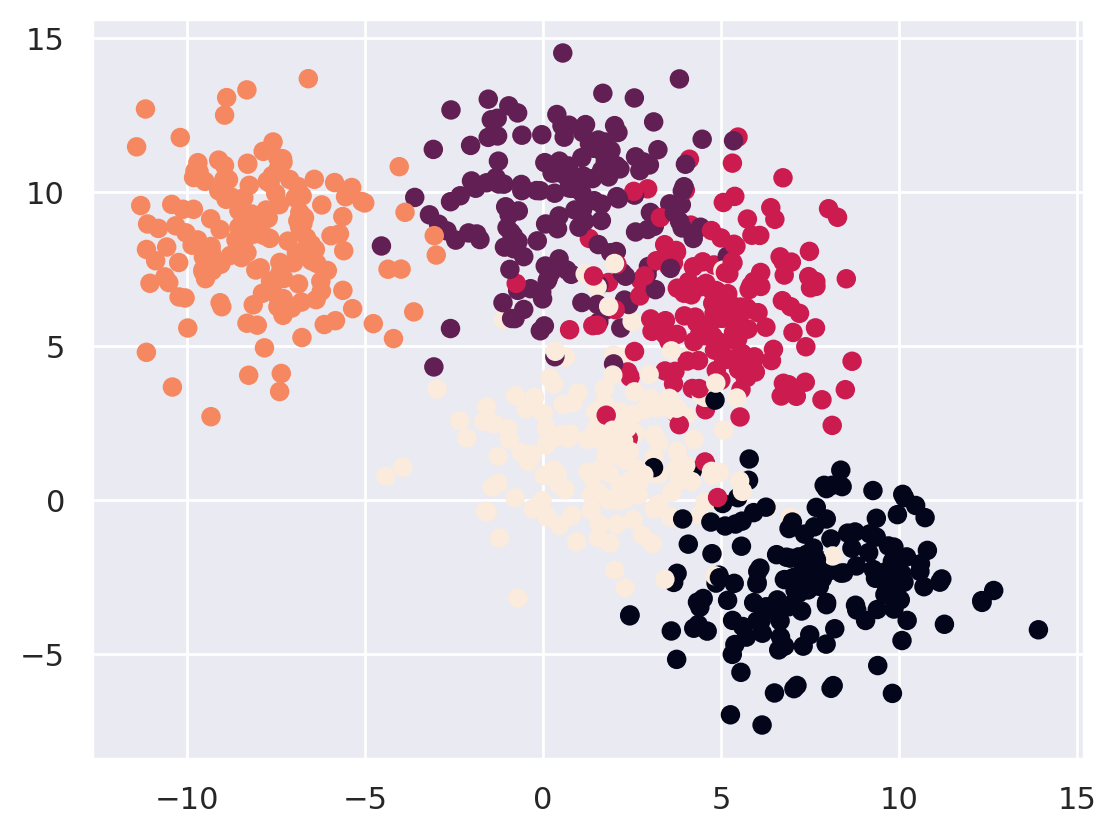

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y);

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

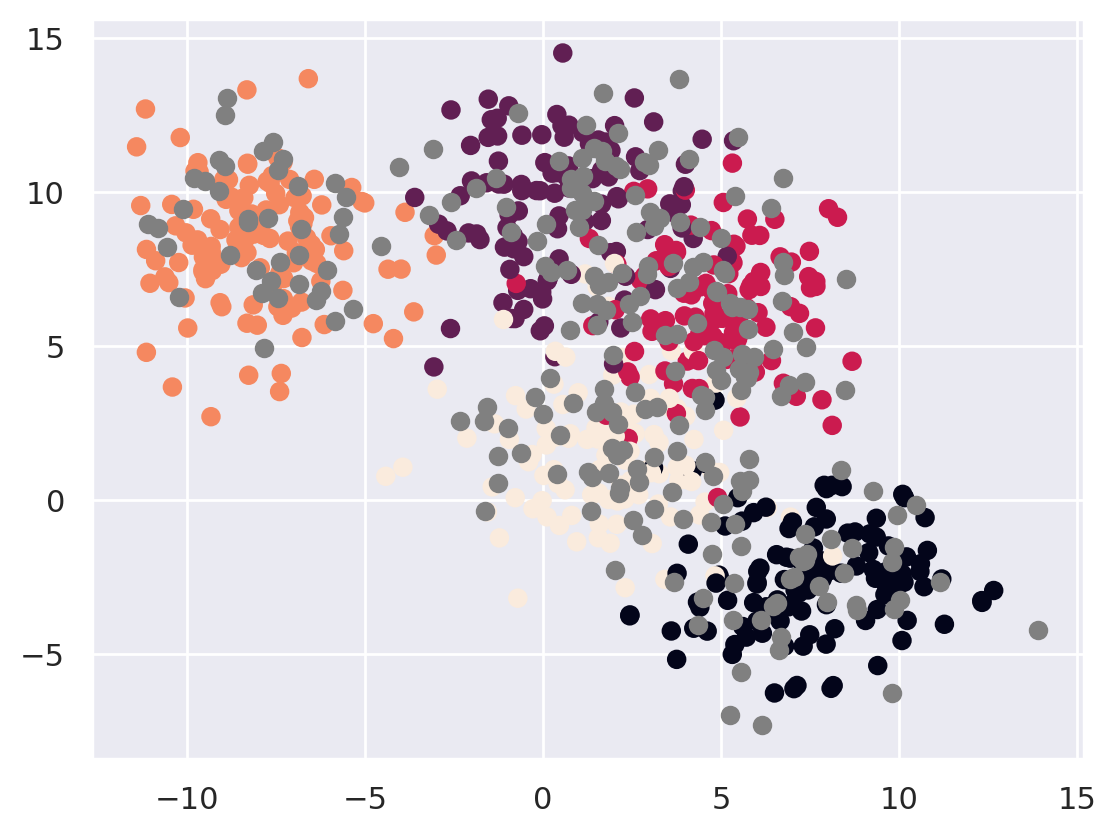

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.scatter(X_test[:, 0], X_test[:, 1], c='grey');

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
predictions = knn.predict(X_test)

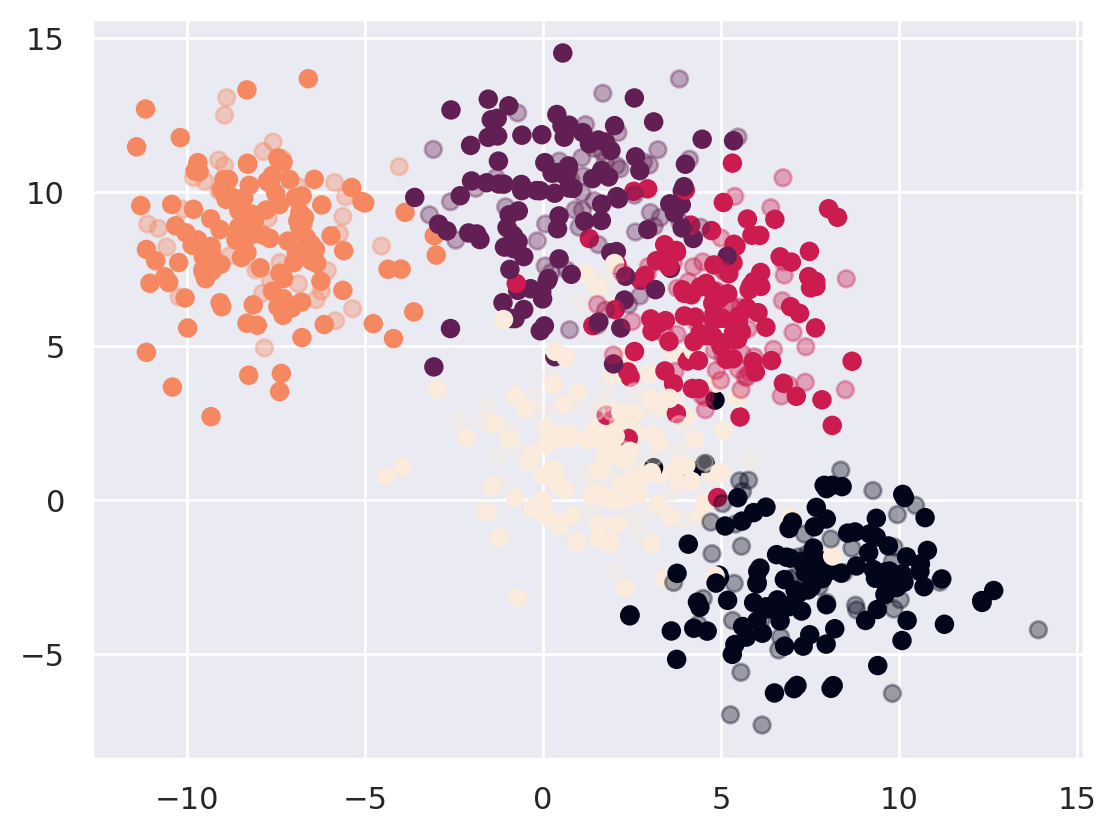

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.scatter(X_test[:, 0], X_test[:, 1], c=predictions,  alpha=0.35);

### 1. Compute accuracy of the baseline

In [ ]:
def accuracy(predictions: np.ndarray, labels: np.ndarray) -> float:
    return len(predictions[predictions == labels]) / len(predictions)
print(0)
print(accuracy(predictions, y_test))

0


ValueError: operands could not be broadcast together with shapes (800,) (240,) 

### 2. Complete `predict_proba` method. You are allowed to use only `numpy` library and your code should work for any number of neighbours.

In [ ]:
from sklearn.base import BaseEstimator

class KNearest(BaseEstimator):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict_proba(self, X):
        """
        return probability for each data point of belonging to each cluster
        return N x M matrix prob, where N is number of test samples and M is number of unique classes
        and prob_{ij} — probability for x_i of belonging to j cluster
        """
        n_classes = np.unique(y).size
        return np.zeros((X.shape[0], n_classes))
        for x in X:
            # find distance from test X to all train samples
            # select n_neighbors elements with lowest distance
            # calculate probabily of each class based on neighbors
            pass

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [ ]:
knn = KNearest(n_neighbors=5)
knn.fit(X_train, y_train)
knn.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

### 3. Compare the accuracy of your algorithm with `sklearn` library.

In [ ]:
pass

### 4. Compare the speed of your algorithm with `sklearn` library.

In [ ]:
pass

### 5. Use `KDTree` structure for fast neighbours searching.
Compare accuracy and speed.

In [ ]:
from sklearn.neighbors import KDTree
KDTree?

In [ ]:
class KNearestWithKDTree(BaseEstimator):
    def __init__(self, n_neighbors=5, leaf_size=30):
        self.leaf_size = leaf_size
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict_proba(self, X):
        """
        return probability for each data point of belonging to each cluster
        return N x M matrix prob, where N is number of test samples and M is number of unique classes
        and prob_{ij} — probability for x_i of belonging to j cluster
        """
        n_classes = np.unique(y).size
        return np.zeros((X.shape[0], n_classes))


    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [ ]:
knn = KNearestWithKDTree()
knn.fit(X_train, y_train)
knn.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

### 6. (optional) Implement `KDTree`
If you have time and desire, you can try to implement `KDTree` algorithm.
Compare accuracy and speed.

In [ ]:
class KDTreeOwn:
    def __init__(self, X, leaf_size=30):
        """
        build tree
        """
        pass

    def query(self, X, k=1):
        """
        query the tree for the k nearest neighbors
        """
        pass

In [ ]:
class KNearestWithKDTreeOwn(BaseEstimator):
    def __init__(self, n_neighbors=5, leaf_size=30):
        self.leaf_size = leaf_size
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict_proba(self, X):
        """
        return probability for each data point of belonging to each cluster
        return N x M matrix prob, where N is number of test samples and M is number of unique classes
        and prob_{ij} — probability for x_i of belonging to j cluster
        """
        n_classes = np.unique(y).size
        return np.zeros((X.shape[0], n_classes))


    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)